# Pandas 시작하기: Series, DataFrame, 결측값 처리, apply, 정렬, 기술통계, 상관관계·공분산 실습

## 실습 목표

실습은 두 종류의 데이터를 사용합니다.

1. **직접 만든 학습자/수강 데이터 DataFrame**  
   - Series와 DataFrame 생성
   - index/columns/values/dtypes/shape 확인
   - 결측값 처리
   - `loc`, `iloc`, 컬럼 추가·삭제
   - `apply`, 정렬, 순위, 유일값 처리

2. **기존 실제 데이터 `boston.csv`**  
   - CSV 로딩
   - 기술통계
   - 변수 간 상관관계와 공분산
   - `corr`, `cov`, `corrwith` 활용

> 참고: `boston.csv`는 교육용 통계 실습 데이터로 사용합니다. 이 노트북에서는 데이터 분석 문법과 통계 계산 방법을 익히는 데 초점을 둡니다.

## 0. 실습 환경 준비

먼저 사용할 라이브러리를 불러옵니다.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

DATA_DIR = Path("./data") 

print("pandas version:", pd.__version__)
print("data directory:", DATA_DIR)

pandas version: 2.3.3
data directory: data


---

# Part 1. Pandas 시작하기

Pandas는 표 형태의 데이터를 다루기 위한 대표적인 파이썬 라이브러리입니다.  
핵심 자료구조는 다음 두 가지입니다.

- **Series**: 1차원 라벨 배열
- **DataFrame**: 2차원 표 형태 자료구조

## 1. Series 생성과 기본 속성

Series는 값과 인덱스를 함께 가지는 1차원 자료구조입니다.

In [2]:
scores = pd.Series([88, 92, 75, 64, 95], index=["민수", "지영", "현우", "수진", "하린"], name="중간점수")
scores

민수    88
지영    92
현우    75
수진    64
하린    95
Name: 중간점수, dtype: int64

In [3]:
print("값(values):", scores.values)
print("인덱스(index):", scores.index)
print("자료형(dtype):", scores.dtype)
print("Series 이름(name):", scores.name)

scores.index.name = "이름"
print("index name:", scores.index.name)
scores

값(values): [88 92 75 64 95]
인덱스(index): Index(['민수', '지영', '현우', '수진', '하린'], dtype='object')
자료형(dtype): int64
Series 이름(name): 중간점수
index name: 이름


이름
민수    88
지영    92
현우    75
수진    64
하린    95
Name: 중간점수, dtype: int64

### Series 인덱싱과 연산

Series는 인덱스 이름으로 접근할 수 있고, NumPy 배열처럼 벡터화 연산도 가능합니다.

In [4]:
print("지영 점수:", scores["지영"])
print("80점 이상 여부")
display(scores >= 80)

bonus_scores = scores + 3
bonus_scores.name = "가산점반영점수"
bonus_scores

지영 점수: 92
80점 이상 여부


이름
민수     True
지영     True
현우    False
수진    False
하린     True
Name: 중간점수, dtype: bool

이름
민수    91
지영    95
현우    78
수진    67
하린    98
Name: 가산점반영점수, dtype: int64

### 실습 1

아래 셀을 실행한 뒤, 직접 값을 바꿔 보세요.

In [5]:
# 실습: 특정 학생의 점수를 선택하고, 평균 이상인 학생만 필터링해 봅니다.
mean_score = scores.mean()
print("평균:", mean_score)

scores[scores >= mean_score]

평균: 82.8


이름
민수    88
지영    92
하린    95
Name: 중간점수, dtype: int64

---

# Part 2. 직접 만든 DataFrame으로 Pandas 기본기 실습

강의자료의 DataFrame 기본 개념을 다루기 위해 학습자 수강 데이터를 직접 만들어 봅니다.  
이 데이터에는 일부러 결측값을 포함했습니다.

## 2. DataFrame 생성

딕셔너리, 리스트, NumPy 배열 등 다양한 형태의 데이터를 DataFrame으로 만들 수 있습니다.

In [6]:
student_data = {
    "이름": ["민수", "지영", "현우", "수진", "하린", "도윤", "서연", "태오"],
    "반": ["A", "A", "B", "B", "A", "B", "A", "B"],
    "도시": ["서울", "부산", "서울", "대전", "부산", "서울", np.nan, "대전"],
    "중간점수": [88, 92, 75, np.nan, 95, 70, 84, 63],
    "기말점수": [91, 87, 79, 85, np.nan, 72, 88, 68],
    "출석률": [0.95, 0.90, 0.85, 0.80, 0.98, np.nan, 0.92, 0.76],
    "프로젝트점수": [90, 85, np.nan, 88, 93, 70, 86, 65],
    "수료여부": [True, True, True, True, True, False, True, False],
}

students = pd.DataFrame(student_data)
students

,이름,반,도시,중간점수,기말점수,출석률,프로젝트점수,수료여부
0,민수,A,서울,88.0,91.0,0.95,90.0,True
1,지영,A,부산,92.0,87.0,0.90,85.0,True
2,현우,B,서울,75.0,79.0,0.85,NaN,True
3,수진,B,대전,NaN,85.0,0.80,88.0,True
4,하린,A,부산,95.0,NaN,0.98,93.0,True
5,도윤,B,서울,70.0,72.0,NaN,70.0,False
6,서연,A,NaN,84.0,88.0,0.92,86.0,True
7,태오,B,대전,63.0,68.0,0.76,65.0,False


## 3. DataFrame 주요 속성 확인

DataFrame은 값(`values`), 행 인덱스(`index`), 열 이름(`columns`), 자료형(`dtypes`), 크기(`shape`) 등의 속성을 가집니다.

In [7]:
print("index:", students.index)
print("columns:", students.columns.tolist())
print("shape:", students.shape)
print("size:", students.size)
print("ndim:", students.ndim)

students.dtypes

index: RangeIndex(start=0, stop=8, step=1)
columns: ['이름', '반', '도시', '중간점수', '기말점수', '출석률', '프로젝트점수', '수료여부']
shape: (8, 8)
size: 64
ndim: 2


이름         object
반          object
도시         object
중간점수      float64
기말점수      float64
출석률       float64
프로젝트점수    float64
수료여부         bool
dtype: object

In [8]:
# values는 실제 데이터 배열을 반환합니다.
students.values[:3]

array([['민수', 'A', '서울', 88.0, 91.0, 0.95, 90.0, True],
       ['지영', 'A', '부산', 92.0, 87.0, 0.9, 85.0, True],
       ['현우', 'B', '서울', 75.0, 79.0, 0.85, nan, True]], dtype=object)

### index와 columns 이름 지정

강의자료처럼 DataFrame의 행 방향 인덱스와 열 방향 인덱스에 이름을 붙일 수 있습니다.

In [9]:
students.index.name = "row_id"
students.columns.name = "columns"
students

columns,이름,반,도시,중간점수,기말점수,출석률,프로젝트점수,수료여부
row_id,,,,,,,,
0,민수,A,서울,88.0,91.0,0.95,90.0,True
1,지영,A,부산,92.0,87.0,0.90,85.0,True
2,현우,B,서울,75.0,79.0,0.85,NaN,True
3,수진,B,대전,NaN,85.0,0.80,88.0,True
4,하린,A,부산,95.0,NaN,0.98,93.0,True
5,도윤,B,서울,70.0,72.0,NaN,70.0,False
6,서연,A,NaN,84.0,88.0,0.92,86.0,True
7,태오,B,대전,63.0,68.0,0.76,65.0,False


## 4. 컬럼 선택, 여러 컬럼 선택, 컬럼 추가

DataFrame에서 하나의 열을 선택하면 Series가 반환됩니다.  
여러 열을 선택하면 DataFrame이 반환됩니다.

In [10]:
# 하나의 컬럼 선택: Series
name_series = students["이름"]
print(type(name_series))
display(name_series)

# 여러 컬럼 선택: DataFrame
selected_df = students[["이름", "반", "중간점수", "기말점수"]]
print(type(selected_df))
selected_df

<class 'pandas.core.series.Series'>


row_id
0    민수
1    지영
2    현우
3    수진
4    하린
5    도윤
6    서연
7    태오
Name: 이름, dtype: object

<class 'pandas.core.frame.DataFrame'>


columns,이름,반,중간점수,기말점수
row_id,,,,
0,민수,A,88.0,91.0
1,지영,A,92.0,87.0
2,현우,B,75.0,79.0
3,수진,B,NaN,85.0
4,하린,A,95.0,NaN
5,도윤,B,70.0,72.0
6,서연,A,84.0,88.0
7,태오,B,63.0,68.0


In [11]:
# 기존 컬럼을 활용하여 새로운 컬럼 만들기
students["평균점수"] = students[["중간점수", "기말점수", "프로젝트점수"]].mean(axis=1)
students["우수여부"] = students["평균점수"] >= 85
students

columns,이름,반,도시,중간점수,기말점수,출석률,프로젝트점수,수료여부,평균점수,우수여부
row_id,,,,,,,,,,
0,민수,A,서울,88.0,91.0,0.95,90.0,True,89.666667,True
1,지영,A,부산,92.0,87.0,0.90,85.0,True,88.000000,True
2,현우,B,서울,75.0,79.0,0.85,NaN,True,77.000000,False
3,수진,B,대전,NaN,85.0,0.80,88.0,True,86.500000,True
4,하린,A,부산,95.0,NaN,0.98,93.0,True,94.000000,True
5,도윤,B,서울,70.0,72.0,NaN,70.0,False,70.666667,False
6,서연,A,NaN,84.0,88.0,0.92,86.0,True,86.000000,True
7,태오,B,대전,63.0,68.0,0.76,65.0,False,65.333333,False


### Series를 이용한 컬럼 입력과 인덱스 정렬

Series를 컬럼에 넣을 때는 Series의 인덱스와 DataFrame의 인덱스가 맞는 위치에 값이 들어갑니다.

In [12]:
# 일부 행에만 멘토링 시간을 입력합니다.
mentoring_hours = pd.Series([2, 3, 1], index=[1, 4, 6])
students["멘토링시간"] = mentoring_hours
students

columns,이름,반,도시,중간점수,기말점수,출석률,프로젝트점수,수료여부,평균점수,우수여부,멘토링시간
row_id,,,,,,,,,,,
0,민수,A,서울,88.0,91.0,0.95,90.0,True,89.666667,True,NaN
1,지영,A,부산,92.0,87.0,0.90,85.0,True,88.000000,True,2.0
2,현우,B,서울,75.0,79.0,0.85,NaN,True,77.000000,False,NaN
3,수진,B,대전,NaN,85.0,0.80,88.0,True,86.500000,True,NaN
4,하린,A,부산,95.0,NaN,0.98,93.0,True,94.000000,True,3.0
5,도윤,B,서울,70.0,72.0,NaN,70.0,False,70.666667,False,NaN
6,서연,A,NaN,84.0,88.0,0.92,86.0,True,86.000000,True,1.0
7,태오,B,대전,63.0,68.0,0.76,65.0,False,65.333333,False,NaN


## 5. loc와 iloc로 행/열 선택

- `loc`: 실제 인덱스 이름 또는 라벨 기반 선택
- `iloc`: 정수 위치 기반 선택

In [13]:
# loc: 인덱스 라벨 기준
students.loc[1]

columns
이름          지영
반            A
도시          부산
중간점수      92.0
기말점수      87.0
출석률        0.9
프로젝트점수    85.0
수료여부      True
평균점수      88.0
우수여부      True
멘토링시간      2.0
Name: 1, dtype: object

In [14]:
# loc: 행 범위와 열 이름을 함께 지정
students.loc[1:4, ["이름", "반", "중간점수", "기말점수", "평균점수"]]

columns,이름,반,중간점수,기말점수,평균점수
row_id,,,,,
1,지영,A,92.0,87.0,88.0
2,현우,B,75.0,79.0,77.0
3,수진,B,NaN,85.0,86.5
4,하린,A,95.0,NaN,94.0


In [15]:
# iloc: 정수 위치 기준
students.iloc[0:3, 0:5]

columns,이름,반,도시,중간점수,기말점수
row_id,,,,,
0,민수,A,서울,88.0,91.0
1,지영,A,부산,92.0,87.0
2,현우,B,서울,75.0,79.0


In [16]:
# Boolean indexing: 조건이 True인 행만 선택
students[students["평균점수"] >= 85]

columns,이름,반,도시,중간점수,기말점수,출석률,프로젝트점수,수료여부,평균점수,우수여부,멘토링시간
row_id,,,,,,,,,,,
0,민수,A,서울,88.0,91.0,0.95,90.0,True,89.666667,True,NaN
1,지영,A,부산,92.0,87.0,0.90,85.0,True,88.000000,True,2.0
3,수진,B,대전,NaN,85.0,0.80,88.0,True,86.500000,True,NaN
4,하린,A,부산,95.0,NaN,0.98,93.0,True,94.000000,True,3.0
6,서연,A,NaN,84.0,88.0,0.92,86.0,True,86.000000,True,1.0


## 6. 컬럼 삭제

`del` 또는 `drop`을 이용해 컬럼을 삭제할 수 있습니다.  
실습에서는 원본을 보존하기 위해 복사본에서 삭제합니다.

In [17]:
students_deleted = students.copy()
del students_deleted["우수여부"]
students_deleted.head()

columns,이름,반,도시,중간점수,기말점수,출석률,프로젝트점수,수료여부,평균점수,멘토링시간
row_id,,,,,,,,,,
0,민수,A,서울,88.0,91.0,0.95,90.0,True,89.666667,NaN
1,지영,A,부산,92.0,87.0,0.90,85.0,True,88.000000,2.0
2,현우,B,서울,75.0,79.0,0.85,NaN,True,77.000000,NaN
3,수진,B,대전,NaN,85.0,0.80,88.0,True,86.500000,NaN
4,하린,A,부산,95.0,NaN,0.98,93.0,True,94.000000,3.0


In [18]:
# 여러 컬럼 삭제는 drop 사용
students_deleted2 = students.drop(columns=["우수여부", "멘토링시간"])
students_deleted2.head()

columns,이름,반,도시,중간점수,기말점수,출석률,프로젝트점수,수료여부,평균점수
row_id,,,,,,,,,
0,민수,A,서울,88.0,91.0,0.95,90.0,True,89.666667
1,지영,A,부산,92.0,87.0,0.90,85.0,True,88.000000
2,현우,B,서울,75.0,79.0,0.85,NaN,True,77.000000
3,수진,B,대전,NaN,85.0,0.80,88.0,True,86.500000
4,하린,A,부산,95.0,NaN,0.98,93.0,True,94.000000


---

# Part 3. 결측값 처리

실제 데이터에는 값이 비어 있는 경우가 많습니다.  
Pandas에서는 결측값을 보통 `NaN`으로 표현하고, `isnull`, `notnull`, `dropna`, `fillna` 등을 사용합니다.

## 7. 결측값 확인

In [19]:
students.isnull()

columns,이름,반,도시,중간점수,기말점수,출석률,프로젝트점수,수료여부,평균점수,우수여부,멘토링시간
row_id,,,,,,,,,,,
0,False,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,True
3,False,False,False,True,False,False,False,False,False,False,True
4,False,False,False,False,True,False,False,False,False,False,False
5,False,False,False,False,False,True,False,False,False,False,True
6,False,False,True,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,True


In [20]:
# 컬럼별 결측값 개수
students.isnull().sum()

columns
이름        0
반         0
도시        1
중간점수      1
기말점수      1
출석률       1
프로젝트점수    1
수료여부      0
평균점수      0
우수여부      0
멘토링시간     5
dtype: int64

In [21]:
# 결측값이 하나라도 있는 행만 확인
students[students.isnull().any(axis=1)]

columns,이름,반,도시,중간점수,기말점수,출석률,프로젝트점수,수료여부,평균점수,우수여부,멘토링시간
row_id,,,,,,,,,,,
0,민수,A,서울,88.0,91.0,0.95,90.0,True,89.666667,True,NaN
2,현우,B,서울,75.0,79.0,0.85,NaN,True,77.000000,False,NaN
3,수진,B,대전,NaN,85.0,0.80,88.0,True,86.500000,True,NaN
4,하린,A,부산,95.0,NaN,0.98,93.0,True,94.000000,True,3.0
5,도윤,B,서울,70.0,72.0,NaN,70.0,False,70.666667,False,NaN
6,서연,A,NaN,84.0,88.0,0.92,86.0,True,86.000000,True,1.0
7,태오,B,대전,63.0,68.0,0.76,65.0,False,65.333333,False,NaN


## 8. dropna로 결측값 제거

`dropna()`는 결측값이 있는 행 또는 열을 제거합니다.  
다만 데이터 손실이 발생할 수 있으므로 실제 분석에서는 신중하게 사용합니다.

In [22]:
# 결측값이 하나라도 있는 행 제거
students_drop_any = students.dropna(how="any")
students_drop_any

columns,이름,반,도시,중간점수,기말점수,출석률,프로젝트점수,수료여부,평균점수,우수여부,멘토링시간
row_id,,,,,,,,,,,
1,지영,A,부산,92.0,87.0,0.9,85.0,True,88.0,True,2.0


In [23]:
# 모든 값이 결측인 행만 제거: 현재 데이터에서는 제거되는 행이 없을 수 있습니다.
students.dropna(how="all")

columns,이름,반,도시,중간점수,기말점수,출석률,프로젝트점수,수료여부,평균점수,우수여부,멘토링시간
row_id,,,,,,,,,,,
0,민수,A,서울,88.0,91.0,0.95,90.0,True,89.666667,True,NaN
1,지영,A,부산,92.0,87.0,0.90,85.0,True,88.000000,True,2.0
2,현우,B,서울,75.0,79.0,0.85,NaN,True,77.000000,False,NaN
3,수진,B,대전,NaN,85.0,0.80,88.0,True,86.500000,True,NaN
4,하린,A,부산,95.0,NaN,0.98,93.0,True,94.000000,True,3.0
5,도윤,B,서울,70.0,72.0,NaN,70.0,False,70.666667,False,NaN
6,서연,A,NaN,84.0,88.0,0.92,86.0,True,86.000000,True,1.0
7,태오,B,대전,63.0,68.0,0.76,65.0,False,65.333333,False,NaN


## 9. fillna로 결측값 채우기

수치형 컬럼은 평균이나 중앙값으로, 범주형 컬럼은 최빈값 또는 별도 문자열로 채우는 방법을 많이 사용합니다.

In [24]:
students_filled = students.copy()

score_cols = ["중간점수", "기말점수", "프로젝트점수", "출석률", "멘토링시간"]
for col in score_cols:
    students_filled[col] = students_filled[col].fillna(students_filled[col].mean())

students_filled["도시"] = students_filled["도시"].fillna("미입력")

# 평균점수는 결측값을 채운 뒤 다시 계산합니다.
students_filled["평균점수"] = students_filled[["중간점수", "기말점수", "프로젝트점수"]].mean(axis=1)
students_filled["우수여부"] = students_filled["평균점수"] >= 85

students_filled

columns,이름,반,도시,중간점수,기말점수,출석률,프로젝트점수,수료여부,평균점수,우수여부,멘토링시간
row_id,,,,,,,,,,,
0,민수,A,서울,88.0,91.000000,0.95,90.000000,True,89.666667,True,2.0
1,지영,A,부산,92.0,87.000000,0.90,85.000000,True,88.000000,True,2.0
2,현우,B,서울,75.0,79.000000,0.85,82.428571,True,78.809524,False,2.0
3,수진,B,대전,81.0,85.000000,0.80,88.000000,True,84.666667,False,2.0
4,하린,A,부산,95.0,81.428571,0.98,93.000000,True,89.809524,True,3.0
5,도윤,B,서울,70.0,72.000000,0.88,70.000000,False,70.666667,False,2.0
6,서연,A,미입력,84.0,88.000000,0.92,86.000000,True,86.000000,True,1.0
7,태오,B,대전,63.0,68.000000,0.76,65.000000,False,65.333333,False,2.0


In [25]:
students_filled.isnull().sum()

columns
이름        0
반         0
도시        0
중간점수      0
기말점수      0
출석률       0
프로젝트점수    0
수료여부      0
평균점수      0
우수여부      0
멘토링시간     0
dtype: int64

---

# Part 4. apply와 사용자 정의 함수

`apply`는 행 또는 열 단위로 함수를 적용할 때 사용합니다.

- `axis=0`: 열 단위 적용
- `axis=1`: 행 단위 적용

## 10. 컬럼 단위 apply

In [26]:
# 각 수치형 컬럼의 범위(max - min)를 계산합니다.
range_func = lambda x: x.max() - x.min()

students_filled[["중간점수", "기말점수", "프로젝트점수", "평균점수"]].apply(range_func, axis=0)

columns
중간점수      32.00000
기말점수      23.00000
프로젝트점수    28.00000
평균점수      24.47619
dtype: float64

## 11. 행 단위 apply

각 학습자의 평균점수와 출석률을 기준으로 평가 등급을 만들어 봅니다.

In [27]:
def assign_grade(row):
    if row["평균점수"] >= 90 and row["출석률"] >= 0.9:
        return "A+"
    elif row["평균점수"] >= 85:
        return "A"
    elif row["평균점수"] >= 75:
        return "B"
    else:
        return "C"

students_filled["평가등급"] = students_filled.apply(assign_grade, axis=1)
students_filled[["이름", "평균점수", "출석률", "평가등급"]]

columns,이름,평균점수,출석률,평가등급
row_id,,,,
0,민수,89.666667,0.95,A
1,지영,88.000000,0.90,A
2,현우,78.809524,0.85,B
3,수진,84.666667,0.80,B
4,하린,89.809524,0.98,A
5,도윤,70.666667,0.88,C
6,서연,86.000000,0.92,A
7,태오,65.333333,0.76,C


In [28]:
# lambda 함수로 간단한 컬럼 만들기
students_filled["수료상태"] = students_filled.apply(
    lambda row: "수료" if row["수료여부"] and row["평균점수"] >= 70 else "미수료",
    axis=1,
)
students_filled[["이름", "수료여부", "평균점수", "수료상태"]]

columns,이름,수료여부,평균점수,수료상태
row_id,,,,
0,민수,True,89.666667,수료
1,지영,True,88.000000,수료
2,현우,True,78.809524,수료
3,수진,True,84.666667,수료
4,하린,True,89.809524,수료
5,도윤,False,70.666667,미수료
6,서연,True,86.000000,수료
7,태오,False,65.333333,미수료


---

# Part 5. 정렬, 순위, 유일값 처리

## 12. sort_index와 sort_values

In [29]:
# 인덱스 기준 정렬
students_filled.sort_index(ascending=False)

columns,이름,반,도시,중간점수,기말점수,출석률,프로젝트점수,수료여부,평균점수,우수여부,멘토링시간,평가등급,수료상태
row_id,,,,,,,,,,,,,
7,태오,B,대전,63.0,68.000000,0.76,65.000000,False,65.333333,False,2.0,C,미수료
6,서연,A,미입력,84.0,88.000000,0.92,86.000000,True,86.000000,True,1.0,A,수료
5,도윤,B,서울,70.0,72.000000,0.88,70.000000,False,70.666667,False,2.0,C,미수료
4,하린,A,부산,95.0,81.428571,0.98,93.000000,True,89.809524,True,3.0,A,수료
3,수진,B,대전,81.0,85.000000,0.80,88.000000,True,84.666667,False,2.0,B,수료
2,현우,B,서울,75.0,79.000000,0.85,82.428571,True,78.809524,False,2.0,B,수료
1,지영,A,부산,92.0,87.000000,0.90,85.000000,True,88.000000,True,2.0,A,수료
0,민수,A,서울,88.0,91.000000,0.95,90.000000,True,89.666667,True,2.0,A,수료


In [30]:
# 값 기준 정렬: 평균점수가 높은 순서
students_filled.sort_values(by="평균점수", ascending=False)

columns,이름,반,도시,중간점수,기말점수,출석률,프로젝트점수,수료여부,평균점수,우수여부,멘토링시간,평가등급,수료상태
row_id,,,,,,,,,,,,,
4,하린,A,부산,95.0,81.428571,0.98,93.000000,True,89.809524,True,3.0,A,수료
0,민수,A,서울,88.0,91.000000,0.95,90.000000,True,89.666667,True,2.0,A,수료
1,지영,A,부산,92.0,87.000000,0.90,85.000000,True,88.000000,True,2.0,A,수료
6,서연,A,미입력,84.0,88.000000,0.92,86.000000,True,86.000000,True,1.0,A,수료
3,수진,B,대전,81.0,85.000000,0.80,88.000000,True,84.666667,False,2.0,B,수료
2,현우,B,서울,75.0,79.000000,0.85,82.428571,True,78.809524,False,2.0,B,수료
5,도윤,B,서울,70.0,72.000000,0.88,70.000000,False,70.666667,False,2.0,C,미수료
7,태오,B,대전,63.0,68.000000,0.76,65.000000,False,65.333333,False,2.0,C,미수료


In [31]:
# 여러 기준으로 정렬: 반 오름차순, 평균점수 내림차순
students_filled.sort_values(by=["반", "평균점수"], ascending=[True, False])

columns,이름,반,도시,중간점수,기말점수,출석률,프로젝트점수,수료여부,평균점수,우수여부,멘토링시간,평가등급,수료상태
row_id,,,,,,,,,,,,,
4,하린,A,부산,95.0,81.428571,0.98,93.000000,True,89.809524,True,3.0,A,수료
0,민수,A,서울,88.0,91.000000,0.95,90.000000,True,89.666667,True,2.0,A,수료
1,지영,A,부산,92.0,87.000000,0.90,85.000000,True,88.000000,True,2.0,A,수료
6,서연,A,미입력,84.0,88.000000,0.92,86.000000,True,86.000000,True,1.0,A,수료
3,수진,B,대전,81.0,85.000000,0.80,88.000000,True,84.666667,False,2.0,B,수료
2,현우,B,서울,75.0,79.000000,0.85,82.428571,True,78.809524,False,2.0,B,수료
5,도윤,B,서울,70.0,72.000000,0.88,70.000000,False,70.666667,False,2.0,C,미수료
7,태오,B,대전,63.0,68.000000,0.76,65.000000,False,65.333333,False,2.0,C,미수료


## 13. rank로 순위 매기기

In [32]:
students_filled["평균점수순위"] = students_filled["평균점수"].rank(ascending=False, method="min")
students_filled[["이름", "평균점수", "평균점수순위"]].sort_values("평균점수순위")

columns,이름,평균점수,평균점수순위
row_id,,,
4,하린,89.809524,1.0
0,민수,89.666667,2.0
1,지영,88.000000,3.0
6,서연,86.000000,4.0
3,수진,84.666667,5.0
2,현우,78.809524,6.0
5,도윤,70.666667,7.0
7,태오,65.333333,8.0


## 14. unique, value_counts, isin

In [33]:
print("도시 unique:", students_filled["도시"].unique())
print("반 unique:", students_filled["반"].unique())

students_filled["도시"].value_counts()

도시 unique: ['서울' '부산' '대전' '미입력']
반 unique: ['A' 'B']


도시
서울     3
부산     2
대전     2
미입력    1
Name: count, dtype: int64

In [34]:
# 서울 또는 부산 학습자만 선택
students_filled[students_filled["도시"].isin(["서울", "부산"])]

columns,이름,반,도시,중간점수,기말점수,출석률,프로젝트점수,수료여부,평균점수,우수여부,멘토링시간,평가등급,수료상태,평균점수순위
row_id,,,,,,,,,,,,,,
0,민수,A,서울,88.0,91.000000,0.95,90.000000,True,89.666667,True,2.0,A,수료,2.0
1,지영,A,부산,92.0,87.000000,0.90,85.000000,True,88.000000,True,2.0,A,수료,3.0
2,현우,B,서울,75.0,79.000000,0.85,82.428571,True,78.809524,False,2.0,B,수료,6.0
4,하린,A,부산,95.0,81.428571,0.98,93.000000,True,89.809524,True,3.0,A,수료,1.0
5,도윤,B,서울,70.0,72.000000,0.88,70.000000,False,70.666667,False,2.0,C,미수료,7.0


---

# Part 6. 기술통계와 요약 통계

`count`, `describe`, `sum`, `mean`, `median`, `var`, `std`, `quantile`, `diff` 등을 실습합니다.

## 15. 직접 만든 DataFrame의 기술통계

In [35]:
students_filled.describe()

columns,중간점수,기말점수,출석률,프로젝트점수,평균점수,멘토링시간,평균점수순위
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.00000
mean,81.000000,81.428571,0.880000,82.428571,81.619048,2.000000,4.50000
std,11.058287,8.050859,0.074258,9.839529,9.212708,0.534522,2.44949
min,63.000000,68.000000,0.760000,65.000000,65.333333,1.000000,1.00000
25%,73.750000,77.250000,0.837500,79.321429,76.773810,2.000000,2.75000
50%,82.500000,83.214286,0.890000,85.500000,85.333333,2.000000,4.50000
75%,89.000000,87.250000,0.927500,88.500000,88.416667,2.000000,6.25000
max,95.000000,91.000000,0.980000,93.000000,89.809524,3.000000,8.00000


In [36]:
score_df = students_filled[["중간점수", "기말점수", "프로젝트점수", "평균점수", "출석률"]]

summary = pd.DataFrame({
    "count": score_df.count(),
    "mean": score_df.mean(),
    "median": score_df.median(),
    "std": score_df.std(),
    "var": score_df.var(),
    "min": score_df.min(),
    "max": score_df.max(),
    "q25": score_df.quantile(0.25),
    "q75": score_df.quantile(0.75),
})
summary

,count,mean,median,std,var,min,max,q25,q75
columns,,,,,,,,,
중간점수,8,81.000000,82.500000,11.058287,122.285714,63.000000,95.000000,73.750000,89.000000
기말점수,8,81.428571,83.214286,8.050859,64.816327,68.000000,91.000000,77.250000,87.250000
프로젝트점수,8,82.428571,85.500000,9.839529,96.816327,65.000000,93.000000,79.321429,88.500000
평균점수,8,81.619048,85.333333,9.212708,84.873988,65.333333,89.809524,76.773810,88.416667
출석률,8,0.880000,0.890000,0.074258,0.005514,0.760000,0.980000,0.837500,0.927500


In [37]:
# diff: 이전 행과의 차이. 시계열 데이터에서 특히 자주 사용합니다.
students_filled.sort_values("평균점수", ascending=False)[["이름", "평균점수"]].assign(
    이전순위와점수차=lambda df: df["평균점수"].diff()
)

columns,이름,평균점수,이전순위와점수차
row_id,,,
4,하린,89.809524,NaN
0,민수,89.666667,-0.142857
1,지영,88.000000,-1.666667
6,서연,86.000000,-2.000000
3,수진,84.666667,-1.333333
2,현우,78.809524,-5.857143
5,도윤,70.666667,-8.142857
7,태오,65.333333,-5.333333


---

# Part 7. 실제 데이터 boston.csv 로딩과 DataFrame 분석

이번에는 기존 실제 데이터인 `boston.csv`를 사용합니다.  
이 데이터는 수치형 컬럼이 많아 기술통계, 상관관계, 공분산 실습에 적합합니다.

## 16. CSV 파일 읽기

In [38]:
boston_path = DATA_DIR / "boston.csv"
boston = pd.read_csv(boston_path)

boston.head()

,Price,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,24.0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,21.6,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,34.7,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,33.4,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,36.2,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [39]:
print("shape:", boston.shape)
print("columns:", boston.columns.tolist())
print("dtypes:")
display(boston.dtypes)

boston.info()

shape: (506, 14)
columns: ['Price', 'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
dtypes:


Price      float64
CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD        float64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Price    506 non-null    float64
 1   CRIM     506 non-null    float64
 2   ZN       506 non-null    float64
 3   INDUS    506 non-null    float64
 4   CHAS     506 non-null    float64
 5   NOX      506 non-null    float64
 6   RM       506 non-null    float64
 7   AGE      506 non-null    float64
 8   DIS      506 non-null    float64
 9   RAD      506 non-null    float64
 10  TAX      506 non-null    float64
 11  PTRATIO  506 non-null    float64
 12  B        506 non-null    float64
 13  LSTAT    506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


## 17. boston.csv의 기본 DataFrame 조작

실제 데이터에서도 앞에서 배운 Pandas 기본기를 동일하게 사용할 수 있습니다.

In [40]:
# 하나의 컬럼 선택: Series
price = boston["Price"]
print(type(price))
price.head()

<class 'pandas.core.series.Series'>


0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: Price, dtype: float64

In [41]:
# 여러 컬럼 선택: DataFrame
boston_small = boston[["Price", "RM", "LSTAT", "PTRATIO", "NOX", "DIS"]]
boston_small.head()

,Price,RM,LSTAT,PTRATIO,NOX,DIS
0,24.0,6.575,4.98,15.3,0.538,4.0900
1,21.6,6.421,9.14,17.8,0.469,4.9671
2,34.7,7.185,4.03,17.8,0.469,4.9671
3,33.4,6.998,2.94,18.7,0.458,6.0622
4,36.2,7.147,5.33,18.7,0.458,6.0622


In [42]:
# loc와 iloc 사용
print("loc 예시")
display(boston.loc[0:4, ["Price", "RM", "LSTAT"]])

print("iloc 예시")
display(boston.iloc[0:5, 0:4])

loc 예시


,Price,RM,LSTAT
0,24.0,6.575,4.98
1,21.6,6.421,9.14
2,34.7,7.185,4.03
3,33.4,6.998,2.94
4,36.2,7.147,5.33


iloc 예시


,Price,CRIM,ZN,INDUS
0,24.0,0.00632,18.0,2.31
1,21.6,0.02731,0.0,7.07
2,34.7,0.02729,0.0,7.07
3,33.4,0.03237,0.0,2.18
4,36.2,0.06905,0.0,2.18


In [43]:
# 조건 필터링: 방 개수 RM이 높고 가격 Price도 높은 지역
boston[(boston["RM"] >= boston["RM"].quantile(0.75)) & (boston["Price"] >= boston["Price"].quantile(0.75))].head()

,Price,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
2,34.7,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,33.4,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,36.2,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
40,34.9,0.03359,75.0,2.95,0.0,0.428,7.024,15.8,5.4011,3.0,252.0,18.3,395.62,1.98
41,26.6,0.12744,0.0,6.91,0.0,0.448,6.770,2.9,5.7209,3.0,233.0,17.9,385.41,4.84


## 18. 실제 데이터의 결측값 확인

In [44]:
boston.isnull().sum()

Price      0
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
dtype: int64

`boston.csv` 자체에는 결측값이 없을 수 있습니다.  
결측값 처리 실습을 위해 일부 값을 의도적으로 비워서 연습용 데이터를 만듭니다.

In [45]:
boston_missing = boston.copy()

# 재현 가능한 실습을 위해 고정된 위치에 결측값을 만듭니다.
boston_missing.loc[[0, 3, 7], "RM"] = np.nan
boston_missing.loc[[2, 5, 9], "LSTAT"] = np.nan
boston_missing.loc[[4, 8], "PTRATIO"] = np.nan

boston_missing.head(10)

,Price,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,24.0,0.00632,18.0,2.31,0.0,0.538,NaN,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,21.6,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,34.7,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,NaN
3,33.4,0.03237,0.0,2.18,0.0,0.458,NaN,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,36.2,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,NaN,396.90,5.33
5,28.7,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3.0,222.0,18.7,394.12,NaN
6,22.9,0.08829,12.5,7.87,0.0,0.524,6.012,66.6,5.5605,5.0,311.0,15.2,395.60,12.43
7,27.1,0.14455,12.5,7.87,0.0,0.524,NaN,96.1,5.9505,5.0,311.0,15.2,396.90,19.15
8,16.5,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5.0,311.0,NaN,386.63,29.93
9,18.9,0.17004,12.5,7.87,0.0,0.524,6.004,85.9,6.5921,5.0,311.0,15.2,386.71,NaN


In [46]:
boston_missing[["RM", "LSTAT", "PTRATIO"]].isnull().sum()

RM         3
LSTAT      3
PTRATIO    2
dtype: int64

In [47]:
# 평균 또는 중앙값으로 결측값 채우기
boston_filled = boston_missing.copy()

boston_filled["RM"] = boston_filled["RM"].fillna(boston_filled["RM"].mean())
boston_filled["LSTAT"] = boston_filled["LSTAT"].fillna(boston_filled["LSTAT"].median())
boston_filled["PTRATIO"] = boston_filled["PTRATIO"].fillna(boston_filled["PTRATIO"].mean())

boston_filled[["RM", "LSTAT", "PTRATIO"]].isnull().sum()

RM         0
LSTAT      0
PTRATIO    0
dtype: int64

## 19. 실제 데이터 기술통계

In [48]:
boston.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,506.0,22.532806,9.197104,5.00000,17.025000,21.20000,25.000000,50.0000
CRIM,506.0,3.593761,8.596783,0.00632,0.082045,0.25651,3.647423,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000


In [49]:
# 관심 변수만 요약
boston[["Price", "RM", "LSTAT", "PTRATIO", "NOX", "DIS", "TAX"]].agg(["count", "mean", "median", "std", "var", "min", "max"])

,Price,RM,LSTAT,PTRATIO,NOX,DIS,TAX
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,22.532806,6.284634,12.653063,18.455534,0.554695,3.795043,408.237154
median,21.200000,6.208500,11.360000,19.050000,0.538000,3.207450,330.000000
std,9.197104,0.702617,7.141062,2.164946,0.115878,2.105710,168.537116
var,84.586724,0.493671,50.994760,4.686989,0.013428,4.434015,28404.759488
min,5.000000,3.561000,1.730000,12.600000,0.385000,1.129600,187.000000
max,50.000000,8.780000,37.970000,22.000000,0.871000,12.126500,711.000000


In [50]:
# 분위수 확인
boston[["Price", "RM", "LSTAT"]].quantile([0.25, 0.5, 0.75, 0.9])

,Price,RM,LSTAT
0.25,17.025,5.8855,6.950
0.50,21.200,6.2085,11.360
0.75,25.000,6.6235,16.955
0.90,34.800,7.1515,23.035


## 20. apply를 실제 데이터에 적용하기

In [51]:
# 컬럼별 범위 계산
boston[["Price", "RM", "LSTAT", "PTRATIO", "NOX", "DIS"]].apply(lambda x: x.max() - x.min())

Price      45.0000
RM          5.2190
LSTAT      36.2400
PTRATIO     9.4000
NOX         0.4860
DIS        10.9969
dtype: float64

In [52]:
# 행 단위 적용: 간단한 가격 구간 라벨 만들기
price_q1 = boston["Price"].quantile(0.25)
price_q3 = boston["Price"].quantile(0.75)

def price_group(row):
    if row["Price"] >= price_q3:
        return "상위가격군"
    elif row["Price"] <= price_q1:
        return "하위가격군"
    else:
        return "중간가격군"

boston_labeled = boston.copy()
boston_labeled["가격구간"] = boston_labeled.apply(price_group, axis=1)
boston_labeled[["Price", "RM", "LSTAT", "가격구간"]].head(10)

,Price,RM,LSTAT,가격구간
0,24.0,6.575,4.98,중간가격군
1,21.6,6.421,9.14,중간가격군
2,34.7,7.185,4.03,상위가격군
3,33.4,6.998,2.94,상위가격군
4,36.2,7.147,5.33,상위가격군
5,28.7,6.430,5.21,상위가격군
6,22.9,6.012,12.43,중간가격군
7,27.1,6.172,19.15,상위가격군
8,16.5,5.631,29.93,하위가격군
9,18.9,6.004,17.10,중간가격군


In [53]:
boston_labeled["가격구간"].value_counts()

가격구간
중간가격군    247
상위가격군    132
하위가격군    127
Name: count, dtype: int64

## 21. 정렬과 순위 실습

In [54]:
# 가격이 높은 순서로 정렬
boston_labeled.sort_values("Price", ascending=False).head(10)

,Price,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,가격구간
283,50.0,0.01501,90.0,1.21,1.0,0.4010,7.923,24.8,5.8850,1.0,198.0,13.6,395.52,3.16,상위가격군
225,50.0,0.52693,0.0,6.20,0.0,0.5040,8.725,83.0,2.8944,8.0,307.0,17.4,382.00,4.63,상위가격군
369,50.0,5.66998,0.0,18.10,1.0,0.6310,6.683,96.8,1.3567,24.0,666.0,20.2,375.33,3.73,상위가격군
370,50.0,6.53876,0.0,18.10,1.0,0.6310,7.016,97.5,1.2024,24.0,666.0,20.2,392.05,2.96,상위가격군
371,50.0,9.23230,0.0,18.10,0.0,0.6310,6.216,100.0,1.1691,24.0,666.0,20.2,366.15,9.53,상위가격군
372,50.0,8.26725,0.0,18.10,1.0,0.6680,5.875,89.6,1.1296,24.0,666.0,20.2,347.88,8.88,상위가격군
186,50.0,0.05602,0.0,2.46,0.0,0.4880,7.831,53.6,3.1992,3.0,193.0,17.8,392.63,4.45,상위가격군
204,50.0,0.02009,95.0,2.68,0.0,0.4161,8.034,31.9,5.1180,4.0,224.0,14.7,390.55,2.88,상위가격군
257,50.0,0.61154,20.0,3.97,0.0,0.6470,8.704,86.9,1.8010,5.0,264.0,13.0,389.70,5.12,상위가격군
195,50.0,0.01381,80.0,0.46,0.0,0.4220,7.875,32.0,5.6484,4.0,255.0,14.4,394.23,2.97,상위가격군


In [55]:
# Price 순위 만들기
boston_labeled["Price_rank"] = boston_labeled["Price"].rank(ascending=False, method="min")
boston_labeled[["Price", "RM", "LSTAT", "Price_rank"]].sort_values("Price_rank").head(10)

,Price,RM,LSTAT,Price_rank
204,50.0,8.034,2.88,1.0
267,50.0,8.297,7.44,1.0
257,50.0,8.704,5.12,1.0
225,50.0,8.725,4.63,1.0
195,50.0,7.875,2.97,1.0
368,50.0,4.970,3.26,1.0
369,50.0,6.683,3.73,1.0
370,50.0,7.016,2.96,1.0
371,50.0,6.216,9.53,1.0
372,50.0,5.875,8.88,1.0


---

# Part 8. 상관관계와 공분산

- **공분산(covariance)**: 두 변수가 함께 변하는 방향과 정도를 나타냅니다. 단위의 영향을 받습니다.
- **상관계수(correlation coefficient)**: 두 변수의 선형 관계 강도를 -1에서 1 사이 값으로 표준화한 지표입니다.

Pandas에서는 다음 메서드를 자주 사용합니다.

- `df.cov()`
- `df.corr()`
- `df.corrwith()`

## 22. 공분산 계산

In [56]:
focus_cols = ["Price", "RM", "LSTAT", "PTRATIO", "NOX", "DIS", "TAX"]

cov_matrix = boston[focus_cols].cov()
cov_matrix

,Price,RM,LSTAT,PTRATIO,NOX,DIS,TAX
Price,84.586724,4.493446,-48.447538,-10.110657,-0.455412,4.840229,-726.255716
RM,4.493446,0.493671,-3.079741,-0.540763,-0.024603,0.303663,-34.583448
LSTAT,-48.447538,-3.079741,50.994760,5.782729,0.488946,-7.473329,654.714520
PTRATIO,-10.110657,-0.540763,5.782729,4.686989,0.047397,-1.059775,168.153141
NOX,-0.455412,-0.024603,0.488946,0.047397,0.013428,-0.187696,13.046286
DIS,4.840229,0.303663,-7.473329,-1.059775,-0.187696,4.434015,-189.664592
TAX,-726.255716,-34.583448,654.714520,168.153141,13.046286,-189.664592,28404.759488


## 23. 상관계수 계산

In [57]:
corr_matrix = boston[focus_cols].corr()
corr_matrix

,Price,RM,LSTAT,PTRATIO,NOX,DIS,TAX
Price,1.000000,0.695360,-0.737663,-0.507787,-0.427321,0.249929,-0.468536
RM,0.695360,1.000000,-0.613808,-0.355501,-0.302188,0.205246,-0.292048
LSTAT,-0.737663,-0.613808,1.000000,0.374044,0.590879,-0.496996,0.543993
PTRATIO,-0.507787,-0.355501,0.374044,1.000000,0.188933,-0.232471,0.460853
NOX,-0.427321,-0.302188,0.590879,0.188933,1.000000,-0.769230,0.668023
DIS,0.249929,0.205246,-0.496996,-0.232471,-0.769230,1.000000,-0.534432
TAX,-0.468536,-0.292048,0.543993,0.460853,0.668023,-0.534432,1.000000


In [58]:
# Price와 다른 변수의 상관관계
price_corr = boston[focus_cols].corrwith(boston["Price"]).sort_values(ascending=False)
price_corr

Price      1.000000
RM         0.695360
DIS        0.249929
NOX       -0.427321
TAX       -0.468536
PTRATIO   -0.507787
LSTAT     -0.737663
dtype: float64

## 24. 상관관계 해석 실습

아래 결과에서 `Price`와 양의 상관관계가 큰 변수, 음의 상관관계가 큰 변수를 찾아봅니다.

In [59]:
price_corr_without_self = price_corr.drop("Price")

print("Price와 가장 양의 상관관계가 큰 변수")
display(price_corr_without_self.sort_values(ascending=False).head(3))

print("Price와 가장 음의 상관관계가 큰 변수")
display(price_corr_without_self.sort_values(ascending=True).head(3))

Price와 가장 양의 상관관계가 큰 변수


RM     0.695360
DIS    0.249929
NOX   -0.427321
dtype: float64

Price와 가장 음의 상관관계가 큰 변수


LSTAT     -0.737663
PTRATIO   -0.507787
TAX       -0.468536
dtype: float64

## 25. 상관관계 시각화

Matplotlib만 사용해서 간단한 상관계수 행렬 이미지를 그립니다.

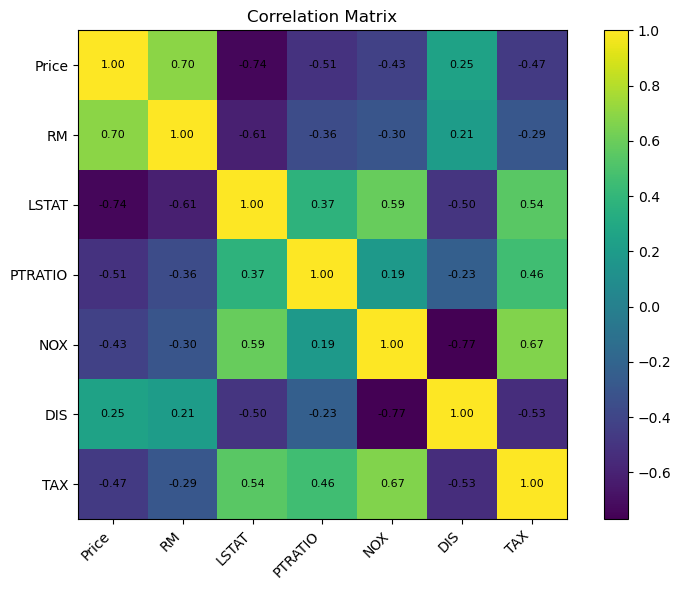

In [60]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix)

ax.set_xticks(range(len(focus_cols)))
ax.set_yticks(range(len(focus_cols)))
ax.set_xticklabels(focus_cols, rotation=45, ha="right")
ax.set_yticklabels(focus_cols)

for i in range(len(focus_cols)):
    for j in range(len(focus_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

---

# Part 9. 종합 실습 문제

아래 문제는 강사가 설명 후 학습자가 직접 완성할 수 있도록 구성했습니다.

## 문제 1. 직접 만든 DataFrame 분석

`students_filled`를 사용하여 다음을 수행해 보세요.

1. `반`별 평균점수를 계산하세요.
2. `평가등급`별 인원 수를 계산하세요.
3. 평균점수가 80점 이상이고 출석률이 0.9 이상인 학습자만 선택하세요.
4. `중간점수`, `기말점수`, `프로젝트점수` 사이의 상관계수를 계산하세요.

In [61]:
# 문제 1 풀이 예시
print("1. 반별 평균점수")
display(students_filled.groupby("반")["평균점수"].mean())

print("2. 평가등급별 인원 수")
display(students_filled["평가등급"].value_counts())

print("3. 평균점수 80 이상, 출석률 0.9 이상")
display(students_filled[(students_filled["평균점수"] >= 80) & (students_filled["출석률"] >= 0.9)])

print("4. 점수 컬럼 간 상관계수")
display(students_filled[["중간점수", "기말점수", "프로젝트점수"]].corr())

1. 반별 평균점수


반
A    88.369048
B    74.869048
Name: 평균점수, dtype: float64

2. 평가등급별 인원 수


평가등급
A    4
B    2
C    2
Name: count, dtype: int64

3. 평균점수 80 이상, 출석률 0.9 이상


columns,이름,반,도시,중간점수,기말점수,출석률,프로젝트점수,수료여부,평균점수,우수여부,멘토링시간,평가등급,수료상태,평균점수순위
row_id,,,,,,,,,,,,,,
0,민수,A,서울,88.0,91.000000,0.95,90.0,True,89.666667,True,2.0,A,수료,2.0
1,지영,A,부산,92.0,87.000000,0.90,85.0,True,88.000000,True,2.0,A,수료,3.0
4,하린,A,부산,95.0,81.428571,0.98,93.0,True,89.809524,True,3.0,A,수료,1.0
6,서연,A,미입력,84.0,88.000000,0.92,86.0,True,86.000000,True,1.0,A,수료,4.0


4. 점수 컬럼 간 상관계수


columns,중간점수,기말점수,프로젝트점수
columns,,,
중간점수,1.000000,0.815146,0.906481
기말점수,0.815146,1.000000,0.868121
프로젝트점수,0.906481,0.868121,1.000000


## 문제 2. boston.csv 분석

`boston`을 사용하여 다음을 수행해 보세요.

1. `Price`가 상위 10%인 행만 선택하세요.
2. `RM` 기준 내림차순으로 정렬하세요.
3. `Price`, `RM`, `LSTAT`, `PTRATIO`의 평균, 표준편차, 중앙값을 계산하세요.
4. `Price`와 가장 상관관계가 큰 변수 5개를 찾으세요.

In [62]:
# 문제 2 풀이 예시
print("1. Price 상위 10%")
threshold = boston["Price"].quantile(0.9)
display(boston[boston["Price"] >= threshold].head())

print("2. RM 기준 내림차순")
display(boston.sort_values("RM", ascending=False).head())

print("3. 관심 변수 요약")
display(boston[["Price", "RM", "LSTAT", "PTRATIO"]].agg(["mean", "std", "median"]))

print("4. Price와 상관관계가 큰 변수 5개")
display(boston.corr(numeric_only=True)["Price"].drop("Price").abs().sort_values(ascending=False).head(5))

1. Price 상위 10%


,Price,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
4,36.2,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
40,34.9,0.03359,75.0,2.95,0.0,0.428,7.024,15.8,5.4011,3.0,252.0,18.3,395.62,1.98
55,35.4,0.01311,90.0,1.22,0.0,0.403,7.249,21.9,8.6966,5.0,226.0,17.9,395.93,4.81
97,38.7,0.12083,0.0,2.89,0.0,0.445,8.069,76.0,3.4952,2.0,276.0,18.0,396.90,4.21
98,43.8,0.08187,0.0,2.89,0.0,0.445,7.820,36.9,3.4952,2.0,276.0,18.0,393.53,3.57


2. RM 기준 내림차순


,Price,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
364,21.9,3.47428,0.0,18.10,1.0,0.718,8.780,82.9,1.9047,24.0,666.0,20.2,354.55,5.29
225,50.0,0.52693,0.0,6.20,0.0,0.504,8.725,83.0,2.8944,8.0,307.0,17.4,382.00,4.63
257,50.0,0.61154,20.0,3.97,0.0,0.647,8.704,86.9,1.8010,5.0,264.0,13.0,389.70,5.12
262,48.8,0.52014,20.0,3.97,0.0,0.647,8.398,91.5,2.2885,5.0,264.0,13.0,386.86,5.91
163,50.0,1.51902,0.0,19.58,1.0,0.605,8.375,93.9,2.1620,5.0,403.0,14.7,388.45,3.32


3. 관심 변수 요약


,Price,RM,LSTAT,PTRATIO
mean,22.532806,6.284634,12.653063,18.455534
std,9.197104,0.702617,7.141062,2.164946
median,21.200000,6.208500,11.360000,19.050000


4. Price와 상관관계가 큰 변수 5개


LSTAT      0.737663
RM         0.695360
PTRATIO    0.507787
INDUS      0.483725
TAX        0.468536
Name: Price, dtype: float64

---

# 마무리 정리

이번 실습에서 다룬 핵심 내용은 다음과 같습니다.

- Series는 1차원 라벨 데이터 구조입니다.
- DataFrame은 행과 열을 가진 2차원 표 형태 데이터 구조입니다.
- `index`, `columns`, `values`, `dtypes`, `shape`, `ndim`, `size`로 구조를 확인할 수 있습니다.
- `loc`는 라벨 기반, `iloc`는 정수 위치 기반 선택에 사용합니다.
- 결측값은 `isnull`, `notnull`, `dropna`, `fillna`로 확인하고 처리할 수 있습니다.
- `apply`는 행 또는 열 단위로 사용자 정의 함수를 적용할 때 유용합니다.
- `sort_index`, `sort_values`, `rank`로 정렬과 순위를 다룰 수 있습니다.
- `describe`, `mean`, `median`, `std`, `var`, `quantile`로 기술통계를 계산합니다.
- `corr`, `cov`, `corrwith`로 상관관계와 공분산을 분석합니다.